In [1]:
import vertexai 
import pandas as pd
from google import genai
import os 
import vertexai 
import pandas as pd
from google import genai
from ci_relevance_utils import relevance_prompt_v1, reasoning_prompt_v1, get_secret, process_and_save_prompt_output, jsonl_to_df

In [2]:
PROJECT_ID = 'proj-sales-recommender-dev'
LOCATION = 'us-central1'
BUCKET = 'sales_recommender_dev_bucket'
DATASET_NAME = "data/cc_classification_sample_with_distances.csv"
SEARCHES_DATASET_NAME = "data/search_evaluation/searches.csv"
SECRET_NAME = "gemini_api_key"
MODEL_ID = "gemini-2.0-flash-001"

In [3]:
# Init vertex 
vertexai.init(project=PROJECT_ID, location=LOCATION)

# Create client using secret manager
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "key.json"
os.environ["GEMINI_API_KEY"] = get_secret(PROJECT_ID, SECRET_NAME)
gemini_client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

In [4]:
# Read dataset
df = pd.read_csv(f"gs://{BUCKET}/{DATASET_NAME}")

In [5]:
def remap_search(search): 
    keywords = ["Drywall", "Ceiling", "Insulation", "EIFS", "Core", "Cultured Stone", "FRP", "Fry Reglet", "Steel", "Door"]
    for word in keywords: 
        if word in search: 
            if word == 'Ceiling': 
                return 'Ceilings'
            return word
    return search

In [6]:
# Rename search terms
df['Search'] = df['Search'].apply(remap_search)
searches_df = pd.read_csv("searches.csv")
search_map={}

# Fetch queries based on search names
for idx, row in searches_df.iterrows(): 
    search = row['SEARCH']
    filter = row['NEW_FILTER']
    search_map[search] = filter

# Apply new queries from the search evaluation
df['Query_new'] = df['Search'].apply(lambda x: search_map[x] if x in search_map else x)
df.drop(columns=['Query'], inplace=True)

In [7]:
# Fetch rows which were not labeled correctly originally (correct used for few-shot)
test_df = df[df['True Relevance'] != df['Relevance']]
test_df.drop(columns=['Relevance'], inplace=True)

/var/folders/t9/ynlywvys31d_71jprr25h4c00000gn/T/ipykernel_46788/1831570390.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.drop(columns=['Relevance'], inplace=True)


In [8]:
# Make directory for predictions
os.makedirs("predictions/relevance/ci_interval", exist_ok=True)

In [40]:
# # Make predictions using standard examples
# process_and_save_prompt_output(gemini_client=gemini_client,
#                                 model_id=MODEL_ID,
#                                 prompt_function=relevance_prompt_v1,
#                                 df=test_df,
#                                 search_col='Search', 
#                                 query_col='Query_new',
#                                 relevance_col='True Relevance', 
#                                 reasoning_col='Reasoning',
#                                 output_filename='predictions/relevance/ci_interval/no_intervals.jsonl', 
# )

In [43]:
responses_df = test_df.drop(columns='Reasoning')

# Read relevance predictions
relevancy = jsonl_to_df("predictions/relevance/ci_interval/no_intervals.jsonl")
relevancy = relevancy[['ProjectID', 'Relevance']]

# Add relevance predictions to the dataframe
responses_df = responses_df.merge(relevancy, on='ProjectID', how='left')

In [45]:
import json 
from tqdm import tqdm

# Make dataframe for reasonings 
reasonings_with_confidence = pd.DataFrame(columns=['ProjectID', 'Reasoning', 'Confidence'])

# Remove true relevance from the responses
responses_no_labels = responses_df.drop(columns=['True Relevance'])

# Generate reasonings and confidence scores for each project
for idx, row in tqdm(responses_no_labels.iterrows(), total=len(responses_no_labels)):

    # Fetch search, query and relevance
    search = row['Search']
    query = row['Query_new']
    relevance = row['Relevance']
    project_id = row['ProjectID']

    # Remove search, query and relevance from the row
    row = row.drop(['Search', 'Query_new', 'Relevance'])

    # Convert row to JSON
    row_json_str = row.to_json()
    cc_project_json_record = json.loads(row_json_str)

    try: 
        # Generate reasoning and confidence
        reasoning_output = reasoning_prompt_v1(gemini_client=gemini_client,
                                               model_id=MODEL_ID,
                                               cc_project_json=cc_project_json_record, 
                                                search=search,
                                                search_terms=query,
                                                relevance_classification=relevance)

        reasoning_output = reasoning_output.replace("```json", "").replace("```", "").strip()

        try: 

            # Parse the JSON output
            json_output = json.loads(reasoning_output)
            reasoning = json_output['Reasoning']
            confidence = json_output['Confidence']
            
            # Add reasoning and confidence for this project to the dataframe
            row_with_confidence = pd.DataFrame([[project_id, reasoning, confidence]], 
                                                columns=['ProjectID', 'Reasoning', 'Confidence'])

            reasonings_with_confidence = pd.concat([reasonings_with_confidence, row_with_confidence], 
                                                    ignore_index=True)

        except json.JSONDecodeError:
            print(f"Error decoding JSON for project {project_id}: {e}")
            continue

    except Exception as e:
        print(f"Error processing project {project_id}: {e}")
        continue

  0%|          | 0/62 [00:00<?, ?it/s]/var/folders/t9/ynlywvys31d_71jprr25h4c00000gn/T/ipykernel_46788/39502365.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  reasonings_with_confidence = pd.concat([reasonings_with_confidence, row_with_confidence], ignore_index=True)
100%|██████████| 62/62 [01:30<00:00,  1.46s/it]


In [54]:
# Add reasonings/confidences to the response 
df_relevance_and_reasoning = responses_df.merge(reasonings_with_confidence, on='ProjectID', how='left')
df_relevances_and_responses.head(5)

,Search,True Relevance,ProjectID,Title,Stage,Valuation_Value,Valuation_Currency,Parameters_Parameter_Ownership,Parameters_Parameter_WorkType,Parameters_Parameter_Structures,...,Details_Detail_Details,Materials_Material,Notes_Note,Latitude,Longitude,Distance,Query_new,Relevance,Reasoning,Confidence
0,Drywall,Very High,1001253356,Pulaski County Jail,General Contractor Award,13108630,USD,County,New,1.0,...,"['[Division 2]: Clearing, Dewatering, Shoring,...","['Clearing', 'Dewatering', 'Shoring', 'Earthwo...",[],37.821060,-92.186820,NaN,(usg NEAR drywall) OR (usg NEAR gypsum) OR ('u...,high,This project is classified as high relevance d...,0.90
1,Drywall,Very High,1001496356,Signal Hill Library,Post Bid,8000000,USD,City,New,1.0,...,[],[],[],33.797217,-118.175151,9.73,(usg NEAR drywall) OR (usg NEAR gypsum) OR ('u...,high,The project is a new construction library with...,0.85
2,Steel,Very High,1001530842,Fire Station 91 - Henderson,Construction Underway,3250000,USD,City,New,1.0,...,[],[],[],35.994630,-115.118970,17.44,"((""STEEL"" OR ""METAL"") AND (JOIST OR DECKING OR...",high,The project is a new construction fire station...,0.90
3,EIFS,High,1001582635,Snohomish County Fire Training Area,Post Bid,4000000,USD,County,New,1.0,...,[],[],[],48.053157,-121.683767,25.71,(eifs NEAR adex) OR (eifs NEAR dryvit) OR (eif...,not relevant,The project is a fire training facility. While...,1.00
4,Insulation,Very High,1001658204,"Halletts Point - Future Phases (Halletts 40, 5...",Construction Documents,200000000,USD,Private,New,6.0,...,[],[],[],40.770391,-73.923967,3.80,"(""mineral wool"") OR (fiberglass) OR (""loose fi...",moderate,"The project is a large, mixed-use development ...",0.50


In [61]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
mapping = {'very high': 'high', 'high': 'high', 'moderate': 'moderate', 'low': 'low', 'very low': 'low'}
labels = ['low', 'moderate', 'high']
encoder = LabelEncoder()
encoder.fit(labels)

# Map labels and encode relevance columns
def map_and_encode_relevance(df, encoder, mapping): 
    return_df = df.copy()
    for col in ['True Relevance', 'Relevance']: 
        return_df.loc[:, col] = return_df[col].str.lower()
        return_df.loc[:, col] = return_df[col].replace(mapping)
        return_df.loc[:, f"{col}_label"] = encoder.transform(return_df[col])
    return return_df

In [62]:
# Filter df by confidence interval and encode relevance columns
def drop_low_confidence_and_encode(df, threshold): 

    df = df.copy()

    # Drop rows with confidence below threshold
    low_confidence_mask = df['Confidence'] < threshold
    df.loc[low_confidence_mask, 'Relevance'] = 'low confidence'

    # Drop rows with "not relevant" or "low confidence" label
    df = df[(df['Relevance'] != 'low confidence') & 
            (df['Relevance'].str.lower() != 'not relevant') &
            (df['True Relevance'].str.lower() != 'not relevant')]
    
    df = map_and_encode_relevance(df, encoder, mapping)
    print(f"Number of relevant predictions after dropping confidence below {threshold}: {len(df)}")

    return df

In [65]:
from sklearn.metrics import f1_score, precision_score, recall_score
from tabulate import tabulate
import numpy as np

headers = ["Version", "F1", "Precision"]
metrics_data = []

# Calculate metrics for different thresholds
# threshold = 0 means only remove "not relevant" rows regardless of confidence
for threshold in [0.0, 0.6, 0.7, 0.8, 0.9]:

    # Drop rows below confidence threshold and encode relevance columns
    dropped_df = drop_low_confidence_and_encode(df_relevances_and_responses, threshold)
    
    # Calculate metrics
    f1 = f1_score(dropped_df['True Relevance_label'], dropped_df['Relevance_label'], average='weighted')
    recall = recall_score(dropped_df['True Relevance_label'], dropped_df['Relevance_label'], average='weighted')
    precision = precision_score(dropped_df['True Relevance_label'], dropped_df[f"Relevance_label"], average='weighted', zero_division=np.nan)
    metrics_data.append([f"Threshold: {str(threshold)}", f1, precision])

table = tabulate(metrics_data, headers = headers, tablefmt="grid")

# Display metrics
print(table)

Number of relevant predictions after dropping confidence below 0.0: 50
Number of relevant predictions after dropping confidence below 0.6: 49
Number of relevant predictions after dropping confidence below 0.7: 49
Number of relevant predictions after dropping confidence below 0.8: 27
Number of relevant predictions after dropping confidence below 0.9: 15
+----------------+----------+-------------+
| Version        |       F1 |   Precision |
+================+==========+=============+
| Threshold: 0.0 | 0.593411 |    0.825767 |
+----------------+----------+-------------+
| Threshold: 0.6 | 0.600542 |    0.823129 |
+----------------+----------+-------------+
| Threshold: 0.7 | 0.600542 |    0.823129 |
+----------------+----------+-------------+
| Threshold: 0.8 | 0.869237 |    0.887346 |
+----------------+----------+-------------+
| Threshold: 0.9 | 0.834568 |    0.862245 |
+----------------+----------+-------------+


/var/folders/t9/ynlywvys31d_71jprr25h4c00000gn/T/ipykernel_46788/527782431.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Relevance', bbox_to_anchor=(1.05, 1), loc='upper left')


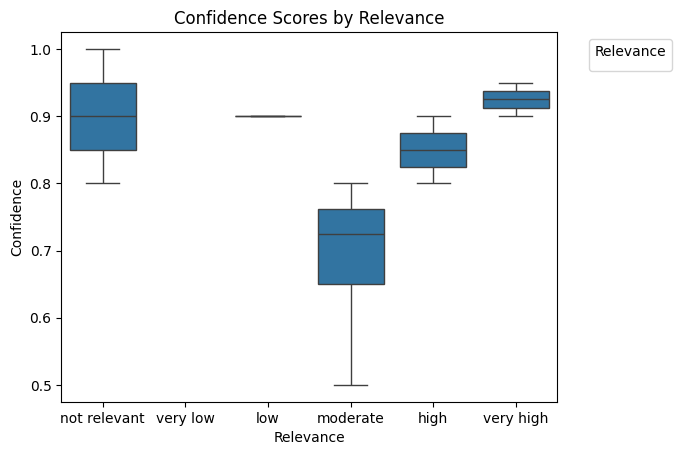

In [64]:
# Scatter plot for Confidence scores
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Relevance and Confidence to count occurrences
grouped_data = df_relevances_and_responses.groupby(['Relevance', 'Confidence']).size().reset_index(name='Count')
relevance_order = ['not relevant', 'very low', 'low', 'moderate', 'high', 'very high']

sns.boxplot(data=grouped_data, x='Relevance', y='Confidence',
                order = relevance_order)

plt.title('Confidence Scores by Relevance')
# plt.xticks(ticks=range(len(relevance_order)), labels=relevance_order, rotation=45)
plt.xlabel('Relevance')
plt.ylabel('Confidence')

# Move the legend outside the graph
plt.legend(title='Relevance', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()